⚠️  Input file not found – using synthetic data.
Paired summary:
         mean        std        min        25%        50%        75%        max
A  54.428564  11.003284  24.470102  48.606774  54.053779  63.353896  72.697546
B  45.104781   9.142385  28.192035  39.064536  44.446733  50.659412  67.507754
Difference summary – mean: 9.3238, median: 9.4232, sd: 15.7322, n: 30


Saved plots: /display_output/A_vs_B.png /display_output/A_vs_B.svg


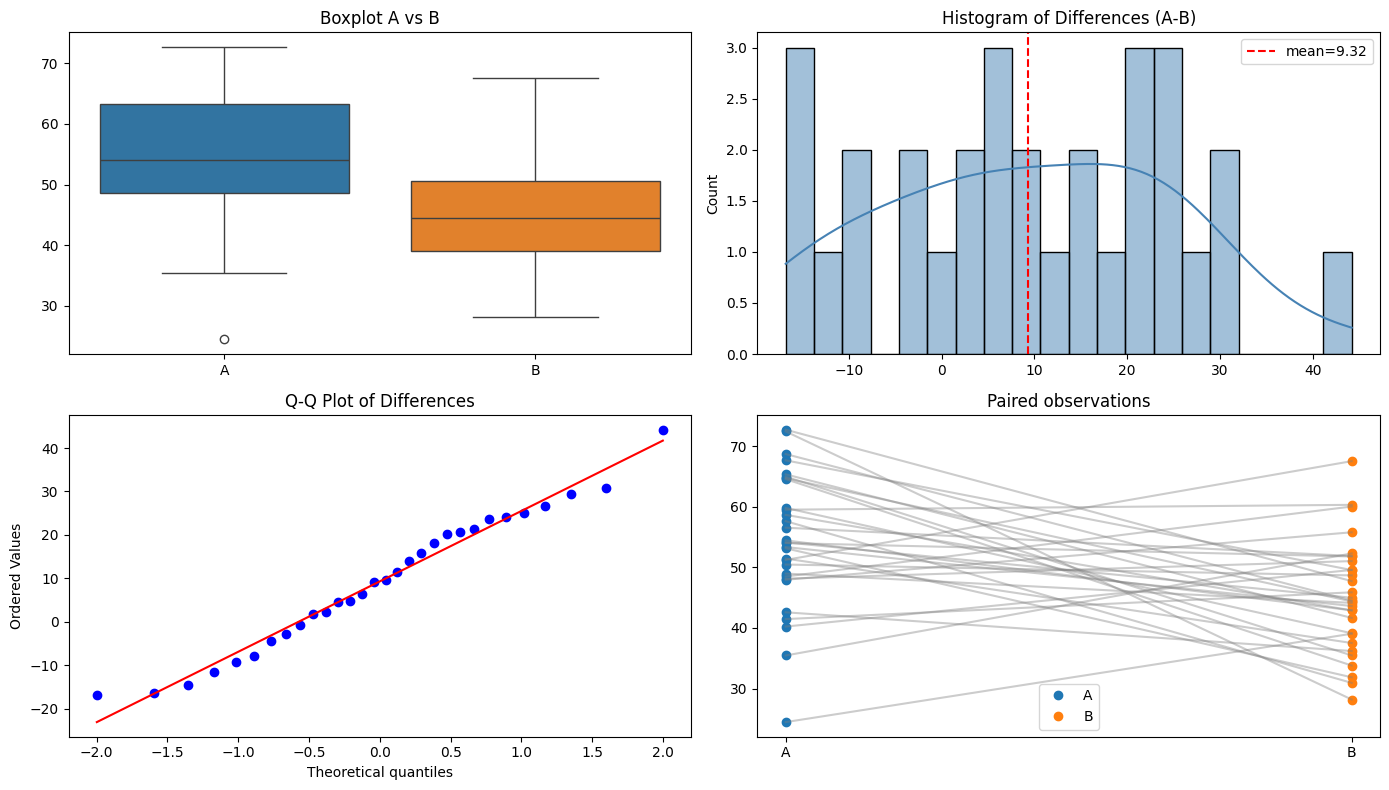

Paired t‑test: statistic=3.24610, p=2.94892e-03, mean_diff=9.32378, 95%CI=(3.44927,15.19830), Cohen_d=0.593, Hedges_g=0.577
Yes


In [1]:
# -------------------------------------------------
# Imports
# -------------------------------------------------
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import ttest_rel, wilcoxon, shapiro, t, probplot, binomtest

# -------------------------------------------------
# Constants
# -------------------------------------------------
INPUT_PATHS = ["/input_data/data.csv", "data.csv"]
OUTPUT_DIR = "/display_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------------------------------------------------
# Load data (with fallback synthetic)
# -------------------------------------------------
def load_data():
    for p in INPUT_PATHS:
        if os.path.isfile(p):
            try:
                return pd.read_csv(p)
            except Exception as e:
                raise IOError(f"Cannot read CSV at {p}: {e}")
    np.random.seed(0)
    n_dummy = 30
    dummy = pd.DataFrame({
        "A": np.random.normal(50, 10, n_dummy),
        "B": np.random.normal(48, 10, n_dummy)
    })
    print("⚠️  Input file not found – using synthetic data.")
    return dummy

df = load_data()
if not {"A", "B"}.issubset(df.columns):
    raise ValueError("Columns A and B are required.")

paired = df[["A", "B"]].dropna()
x, y = paired["A"].values, paired["B"].values
n = len(paired)
if n < 2:
    raise ValueError("Not enough paired observations.")

# -------------------------------------------------
# Difference vector & basic stats
# -------------------------------------------------
diff = x - y
mean_diff = diff.mean()
sd_diff = diff.std(ddof=1)

# -------------------------------------------------
# Normality test (guard for n>=3)
# -------------------------------------------------
sh_stat = sh_p = np.nan
use_wilcoxon = False
if 3 <= n <= 5000:
    sh_stat, sh_p = shapiro(diff)
    use_wilcoxon = sh_p < 0.05

# -------------------------------------------------
# Statistical test with Wilcoxon fallback
# -------------------------------------------------
if use_wilcoxon:
    try:
        stat, p_val = wilcoxon(diff, alternative="two-sided", zero_method="wilcox")
        test_name = "Wilcoxon signed‑rank"
    except ValueError:
        nz = diff[diff != 0]
        m = len(nz)
        if m == 0:
            stat, p_val = np.nan, 1.0
            test_name = "No differences (all zeros)"
        else:
            k = (nz > 0).sum()
            p_val = binomtest(k, m, p=0.5, alternative="two-sided").pvalue
            stat = np.nan
            test_name = "Sign test (fallback)"
else:
    stat, p_val = ttest_rel(x, y)
    test_name = "Paired t‑test"

# -------------------------------------------------
# Effect sizes
# -------------------------------------------------
cohens_d = mean_diff / sd_diff if sd_diff != 0 else np.nan
hedges_g = (cohens_d * (1 - 3 / (4 * n - 9))) if not np.isnan(cohens_d) and n > 3 else np.nan

# -------------------------------------------------
# 95 % CI for mean difference (t‑based)
# -------------------------------------------------
alpha = 0.05
tcrit = t.ppf(1 - alpha / 2, df=n - 1)
se = sd_diff / np.sqrt(n)
ci_low = mean_diff - tcrit * se
ci_high = mean_diff + tcrit * se

# -------------------------------------------------
# Significance decision
# -------------------------------------------------
# Cast to native Python bool to avoid JSON serialization issues
significant = bool(p_val < 0.05)

# -------------------------------------------------
# Descriptive statistics & prints
# -------------------------------------------------
print("Paired summary:\n", paired.describe().T[["mean","std","min","25%","50%","75%","max"]])
print(f"Difference summary – mean: {mean_diff:.4f}, median: {np.median(diff):.4f}, sd: {sd_diff:.4f}, n: {n}")

# -------------------------------------------------
# Visualisations
# -------------------------------------------------
plt.figure(figsize=(14, 8))

# Boxplot A vs B
plt.subplot(2, 2, 1)
sns.boxplot(data=paired[["A", "B"]])
plt.title("Boxplot A vs B")

# Histogram of differences
plt.subplot(2, 2, 2)
sns.histplot(diff, kde=True, bins=20, color="steelblue")
plt.axvline(mean_diff, color="red", linestyle="--", label=f"mean={mean_diff:.2f}")
plt.title("Histogram of Differences (A‑B)")
plt.legend()

# Q‑Q plot
plt.subplot(2, 2, 3)
probplot(diff, dist="norm", plot=plt)
plt.title("Q‑Q Plot of Differences")

# Paired scatter with lines
plt.subplot(2, 2, 4)
plt.plot([1]*n, x, "o", label="A")
plt.plot([2]*n, y, "o", label="B")
for xi, yi in zip(x, y):
    plt.plot([1, 2], [xi, yi], color="gray", alpha=0.4)
plt.xticks([1, 2], ["A", "B"])
plt.title("Paired observations")
plt.legend()

plt.tight_layout()
fig_path_png = os.path.join(OUTPUT_DIR, "A_vs_B.png")
fig_path_svg = os.path.join(OUTPUT_DIR, "A_vs_B.svg")
plt.savefig(fig_path_png, dpi=150)
plt.savefig(fig_path_svg)
print("Saved plots:", fig_path_png, fig_path_svg)
plt.show()

# -------------------------------------------------
# Reporting (description then final Yes/No)
# -------------------------------------------------
print(
    f"{test_name}: statistic={stat:.5f}, p={p_val:.5e}, mean_diff={mean_diff:.5f}, "
    f"95%CI=({ci_low:.5f},{ci_high:.5f}), Cohen_d={cohens_d:.3f}, Hedges_g={hedges_g:.3f}"
)
print("Yes" if significant else "No")

# -------------------------------------------------
# Save results
# -------------------------------------------------
# Final Yes/No
with open(os.path.join(OUTPUT_DIR, "final_result.txt"), "w") as f:
    f.write("Yes" if significant else "No")

# JSON summary
results = {
    "test": test_name,
    "statistic": None if np.isnan(stat) else float(stat),
    "p_value": float(p_val),
    "n": n,
    "mean_difference": float(mean_diff),
    "ci_low": float(ci_low),
    "ci_high": float(ci_high),
    "cohens_d": None if np.isnan(cohens_d) else float(cohens_d),
    "hedges_g": None if np.isnan(hedges_g) else float(hedges_g),
    "significant": significant,
    "shapiro_p": None if np.isnan(sh_p) else float(sh_p)
}
with open(os.path.join(OUTPUT_DIR, "stat_results.json"), "w") as f:
    json.dump(results, f, indent=2)
